In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import torch
import torch.nn as nn
from tqdm import tqdm
from torch.utils.data import DataLoader,TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    KFold,
    train_test_split
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

/home/anmino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/anmino/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("train.csv")

In [4]:
df.head(2)

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0


In [5]:
df.drop("id",axis=1,inplace=True)

In [6]:
df.head(1)

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0


In [7]:
print(f"Duplicate: {df.duplicated().sum() / len(df):.2f}%")

Duplicate: 0.00%


In [8]:
df.duplicated().sum() / len(df)

0.003788

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

0

In [11]:
df["Sex"] = pd.get_dummies(df["Sex"],drop_first=True,dtype="int")

In [12]:
x = df.drop("Calories",axis=1).values
y = df["Calories"].values

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [14]:
scaler1 = StandardScaler()
x_train = scaler1.fit_transform(x_train)
x_test = scaler1.transform(x_test)

In [15]:
scaler2 = StandardScaler()
y_train = scaler2.fit_transform(y_train.reshape(-1,1))
y_test = scaler2.transform(y_test.reshape(-1,1))

In [16]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)

y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [17]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

test_dataset = TensorDataset(
    x_test,
    y_test
)

In [18]:
train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    batch_size=100
)

test_loader = DataLoader(
    test_dataset,
    shuffle=True,
    batch_size=100
)

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.fc1 = nn.Linear(dim,dim)
        self.ln1 = nn.LayerNorm(dim)

        self.fc2 = nn.Linear(dim,dim)
        self.ln2 = nn.LayerNorm(dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        d = x
        out = self.fc1(x)
        out = self.ln1(out)
        out = self.relu(out)

        out = self.fc2(out)
        out = self.ln2(out)

        out = out + d

        out = self.relu(out)

        return out
    

class MyModel(nn.Module):
    def __init__(self,input_dim):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim,128),
            nn.LayerNorm(128),
            nn.ReLU()
        )
        self.res1 = ResidualBlock(128)
        self.res2 = ResidualBlock(128)

        self.output = nn.Linear(128,1)

    def forward(self,x):
        x = self.input_layer(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.output(x)
        return x


In [20]:
model = MyModel(7)

In [21]:
for name,param in model.named_parameters():
    print(f"Parameters: {name} \t\t| \t\tShape: {param.shape}")

Parameters: input_layer.0.weight 		| 		Shape: torch.Size([128, 7])
Parameters: input_layer.0.bias 		| 		Shape: torch.Size([128])
Parameters: input_layer.1.weight 		| 		Shape: torch.Size([128])
Parameters: input_layer.1.bias 		| 		Shape: torch.Size([128])
Parameters: res1.fc1.weight 		| 		Shape: torch.Size([128, 128])
Parameters: res1.fc1.bias 		| 		Shape: torch.Size([128])
Parameters: res1.ln1.weight 		| 		Shape: torch.Size([128])
Parameters: res1.ln1.bias 		| 		Shape: torch.Size([128])
Parameters: res1.fc2.weight 		| 		Shape: torch.Size([128, 128])
Parameters: res1.fc2.bias 		| 		Shape: torch.Size([128])
Parameters: res1.ln2.weight 		| 		Shape: torch.Size([128])
Parameters: res1.ln2.bias 		| 		Shape: torch.Size([128])
Parameters: res2.fc1.weight 		| 		Shape: torch.Size([128, 128])
Parameters: res2.fc1.bias 		| 		Shape: torch.Size([128])
Parameters: res2.ln1.weight 		| 		Shape: torch.Size([128])
Parameters: res2.ln1.bias 		| 		Shape: torch.Size([128])
Parameters: res2.fc2.weight 		| 		

In [22]:
for name,module in model.named_modules():
    print(name,module)

 MyModel(
  (input_layer): Sequential(
    (0): Linear(in_features=7, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (2): ReLU()
  )
  (res1): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (relu): ReLU()
  )
  (res2): ResidualBlock(
    (fc1): Linear(in_features=128, out_features=128, bias=True)
    (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (fc2): Linear(in_features=128, out_features=128, bias=True)
    (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
    (relu): ReLU()
  )
  (output): Linear(in_features=128, out_features=1, bias=True)
)
input_layer Sequential(
  (0): Linear(in_features=7, out_features=128, bias=True)
  (1

In [23]:
loss_function = nn.MSELoss()

optimizer_fun = torch.optim.AdamW(
    model.parameters(),
    lr=0.01,
    weight_decay=0.01
)

In [24]:
train_loss_hist = []
test_loss_hist = []

epochs = 10

process_bar = tqdm(range(epochs),colour="red")
for epoch in process_bar:
    model.train()
    total_train_loss = 0
    for batch_x,batch_y in train_loader:
        optimizer_fun.zero_grad()
        train_pred = model(batch_x)
        loss = loss_function(train_pred,batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer_fun.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        total_test_loss = 0
        for batch_x_test,batch_y_test in test_loader:
            test_pred = model(batch_x_test)
            test_loss = loss_function(test_pred,batch_y_test)
            total_test_loss += test_loss.item()
        avg_test_loss = total_test_loss / len(test_loader)

        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epoch":epoch,
            "Train Loss":avg_train_loss,
            "Test Loss":avg_test_loss,
            "Optimizer":optimizer_fun.state_dict(),
            "Model":model.state_dict()
        },f"shap_models/checkpoints_{epoch + 1}.pth")

        process_bar.set_postfix({
            "Epoch":epoch + 1,
            "Train Loss":f"{avg_train_loss:.4f}",
            "Test Loss":f"{avg_test_loss:.4f}"
        })

100%|██████████| 10/10 [04:18<00:00, 25.85s/it, Epoch=10, Train Loss=0.0042, Test Loss=0.0037]


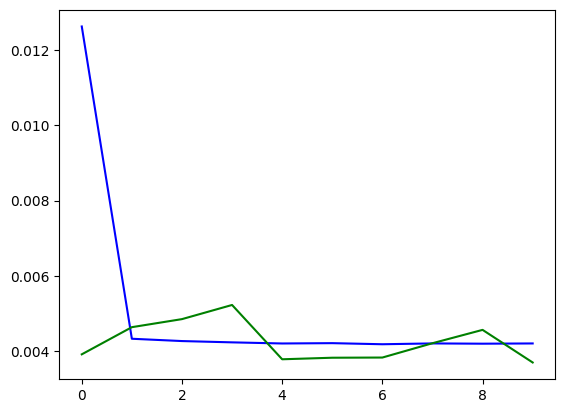

In [25]:
plt.plot(train_loss_hist,label="train",color="blue")
plt.plot(test_loss_hist,label="test",color="green")

In [26]:
model.eval()
train_actual = []
train_pred_data = []
with torch.no_grad():
    for batch_metrix_x,batch_metrix_y in train_loader:
        prediction_metrix = model(batch_metrix_x)
        train_pred_data.extend(prediction_metrix)
        train_actual.extend(batch_metrix_y)

In [27]:
train_actual = scaler2.inverse_transform(np.array(train_actual).reshape(-1,1))
train_pred_data = scaler2.inverse_transform(np.array(train_pred_data).reshape(-1,1))

In [28]:
test_actual_data = []
test_pred_data = []
with torch.no_grad():
    for batch_test_x,batch_test_y in test_loader:
        prediction_test = model(batch_test_x)
        test_pred_data.extend(prediction_test)
        test_actual_data.extend(batch_test_y)

In [29]:
test_actual_data = scaler2.inverse_transform(np.array(test_actual_data).reshape(-1,1))
test_pred_data = scaler2.inverse_transform(np.array(test_pred_data).reshape(-1,1))

In [31]:
print("==============TRAIN===============")
print(f"MSE: {mean_squared_error(train_actual,train_pred_data)}")
print(f"MAE: {mean_absolute_error(train_actual,train_pred_data)}")
print(f"R2: {r2_score(train_actual,train_pred_data)}")

print("==============TEST===============")
print(f"MSE: {mean_squared_error(test_actual_data,test_pred_data)}")
print(f"MAE: {mean_absolute_error(test_actual_data,test_pred_data)}")
print(f"R2: {r2_score(test_actual_data,test_pred_data)}")

==============TRAIN===============
MSE: 14.60587215423584
MAE: 2.319711923599243
R2: 0.9962521195411682
==============TEST===============
MSE: 14.433064460754395
MAE: 2.3149383068084717
R2: 0.9962792992591858


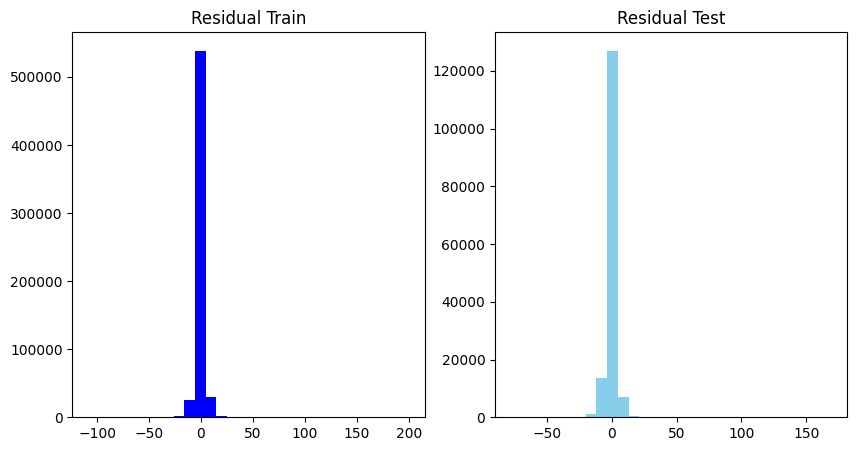

In [38]:
residual_data_train = train_actual - train_pred_data

residual_data_test = test_actual_data - test_pred_data

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(residual_data_train,bins=30,color="blue")
plt.title("Residual Train")

plt.subplot(1,2,2)
plt.hist(residual_data_test,bins=30,color="skyblue")
plt.title("Residual Test")

plt.show()

In [ ]:
f_names = ['Sex', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']

In [254]:
background = x_train[:100]

In [255]:
background.shape

torch.Size([100, 7])

In [256]:
explainer = shap.GradientExplainer(
    model,
    background
)

In [257]:
sample = x_test[0:1]

In [258]:
sample.shape



torch.Size([1, 7])

In [259]:
shap_values = explainer.shap_values(sample)

In [260]:
shap_values.shape

(1, 7, 1)

In [261]:
shap_values = np.array(shap_values)
print(shap_values.shape)
shap_values = shap_values.squeeze()
print(shap_values.shape)

(1, 7, 1)
(7,)


In [262]:
for f,s in zip(f_names,shap_values):
    print(f"{f}     \t\t|     {s:.4f}")

Sex     		|     -0.0167
Age     		|     -0.1217
Height     		|     -0.0013
Weight     		|     -0.0123
Duration     		|     -0.6176
Heart_Rate     		|     -0.0552
Body_Temp     		|     -0.0073


In [263]:
with torch.no_grad():
    shap_pred_varify = model(sample).item()
print(f"Scaled Prediction Verify: {shap_pred_varify}")
print(f"Actual Prediction: {scaler2.inverse_transform(np.array(shap_pred_varify).reshape(-1,1))}")

Scaled Prediction Verify: -0.8218521475791931
Actual Prediction: [[37.07788024]]


In [264]:
x_train.shape

torch.Size([597727, 7])

In [265]:
with torch.no_grad():
    background_pred = model(background)

base_value = background_pred.mean().item()
print(base_value)

-0.051880303770303726


In [266]:
type(explainer)

shap.explainers._gradient.GradientExplainer

In [269]:
exp = shap.Explanation(
    values=shap_values,
    base_values=base_value,
    data=x_test[0].numpy(),
    feature_names=f_names
)

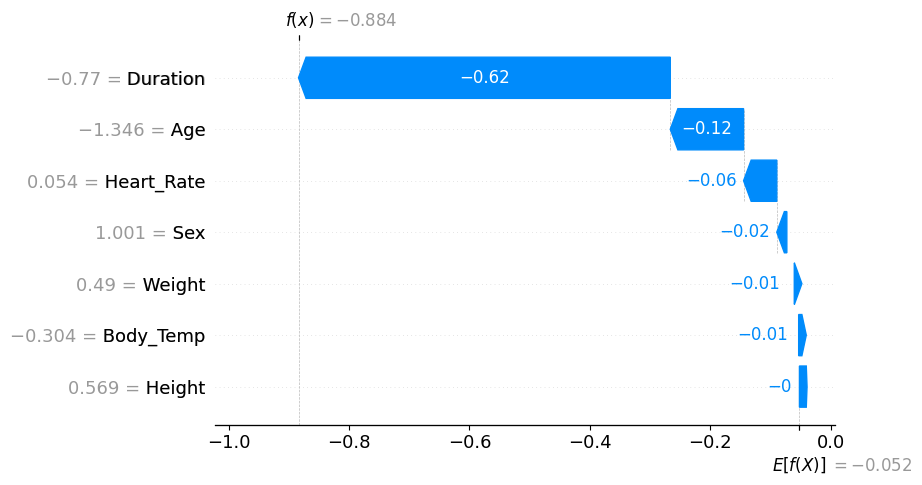

In [270]:
shap.plots.waterfall(exp)

In [ ]:
a = -0.892
print(f"{scaler2.inverse_transform(np.array(a).reshape(-1,1))[0][0]}")

32.69877204411461

In [271]:
base_real = scaler2.inverse_transform(
    np.array([[base_value]])
)[0,0]

pred_real = scaler2.inverse_transform(
    np.array([[shap_pred_varify]])
)[0,0]

print(base_real)
print(pred_real)

85.14478317533208
37.07788024191453


/tmp/ipykernel_5202/2671598194.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


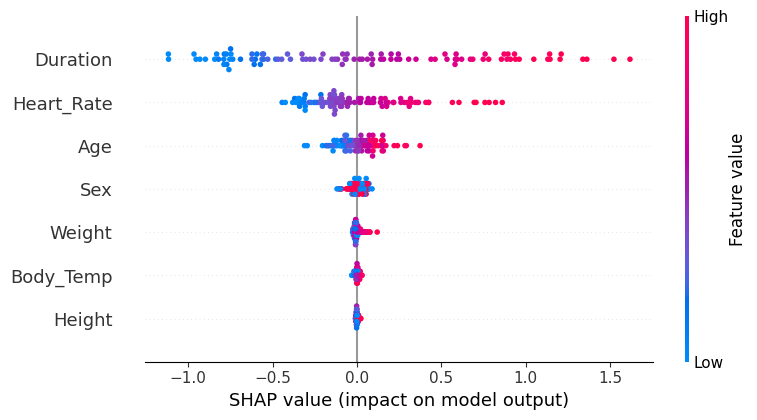

In [273]:
samples = x_test[:100]

shap_values_all = explainer.shap_values(samples)

shap_values_all = np.array(
    shap_values_all
).squeeze()

shap.summary_plot(
    shap_values_all,
    samples.numpy(),
    feature_names=f_names
)